# 01 — EDA: Plant Diseases Dataset (38 clases)

**Objetivo:** overview del dataset antes de entrenar EfficientNet.

- Distribución por clase (desbalance)
- Muestras visuales
- Tamaños de imagen

**Datos:** carpetas `train/`/`valid/` (Kaggle) o Hugging Face `geraldmc/plantvillage-full` (mismas 38 clases).

In [1]:
%pip install -q datasets matplotlib seaborn pandas pillow tqdm

import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 5)

OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
rng = random.Random(42)
print("Figuras →", OUT_DIR.resolve())

Note: you may need to restart the kernel to use updated packages.


Figuras → /teamspace/studios/this_studio/plant-disease-detector/notebooks/eda_outputs


## 1. Cargar datos

In [2]:
def find_data_dir():
    candidates = [
        Path("../data/plantvillage"),
        Path("data/plantvillage"),
        Path("/teamspace/studios/this_studio/plant-disease-detector/data/plantvillage"),
    ]
    for base in [Path("/kaggle/input"), Path("/teamspace")]:
        if base.exists():
            for root, dirs, _ in os.walk(base):
                if "train" in dirs and "valid" in dirs:
                    return Path(root)
                if len(root.split(os.sep)) > 12:
                    break
    for c in candidates:
        if (c / "train").is_dir() and (c / "valid").is_dir():
            return c
    return None

DATA_DIR = find_data_dir()
USE_HF = DATA_DIR is None

if USE_HF:
    print("Cargando desde Hugging Face (PlantVillage, 38 clases)...")
    from datasets import load_dataset
    hf = load_dataset("geraldmc/plantvillage-full", revision="v0.1.0")
    print("Splits HF:", list(hf.keys()))
    if "test" in hf or "validation" in hf:
        train_hf = hf["train"]
        valid_key = next(k for k in ("test", "validation", "valid") if k in hf)
        valid_hf = hf[valid_key]
        print(f"Valid desde split HF: {valid_key}")
    else:
        # Un solo shard: columna 'split' = train | test
        full = hf["train"]
        print("Columnas:", full.column_names)
        train_hf = full.filter(lambda x: x["split"] == "train")
        valid_hf = full.filter(lambda x: x["split"] == "test")
        print("Valid desde columna split=test")
    print(train_hf, valid_hf)
else:
    print("Datos locales:", DATA_DIR.resolve())
    train_hf = valid_hf = None

Cargando desde Hugging Face (PlantVillage, 38 clases)...


Splits HF: ['train']
Columnas: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']


Filter:   0%|          | 0/54304 [00:00<?, ? examples/s]

Filter:   0%|          | 0/54304 [00:00<?, ? examples/s]

Valid desde columna split=test
Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 43356
}) Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 10948
})


In [3]:
def count_folders(split_dir):
    c = Counter()
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            n = len([p for p in cls_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
            c[cls_dir.name] = n
    return c

if USE_HF:
    train_counts = Counter(train_hf["class_label"])
    valid_counts = Counter(valid_hf["class_label"])
else:
    train_counts = count_folders(DATA_DIR / "train")
    valid_counts = count_folders(DATA_DIR / "valid")

n_train, n_valid = sum(train_counts.values()), sum(valid_counts.values())
n_classes = len(train_counts)
print(f"Clases: {n_classes} | Train: {n_train:,} | Valid: {n_valid:,} | Total: {n_train+n_valid:,}")

Clases: 38 | Train: 43,356 | Valid: 10,948 | Total: 54,304


## 2. Distribución de clases

In [4]:
df = pd.DataFrame({"clase": list(train_counts.keys()), "train": list(train_counts.values())})
df = df.merge(
    pd.DataFrame({"clase": list(valid_counts.keys()), "valid": list(valid_counts.values())}),
    on="clase", how="outer",
).fillna(0)
df["total"] = df["train"] + df["valid"]
df = df.sort_values("total", ascending=False).reset_index(drop=True)
ratio = df["total"].max() / max(df["total"].min(), 1)
display(df.head(10))
print(f"Desbalance max/min ≈ {ratio:.1f}x")

,clase,train,valid,total
0,Orange___Haunglongbing_(Citrus_greening),4351,1156,5507
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4288,1069,5357
2,Soybean___healthy,4094,996,5090
3,Peach___Bacterial_spot,1839,458,2297
4,Tomato___Bacterial_spot,1703,424,2127
5,Tomato___Late_blight,1527,382,1909
6,Squash___Powdery_mildew,1468,367,1835
7,Tomato___Septoria_leaf_spot,1411,360,1771
8,Tomato___Spider_mites Two-spotted_spider_mite,1340,336,1676
9,Apple___healthy,1321,324,1645


Desbalance max/min ≈ 36.2x


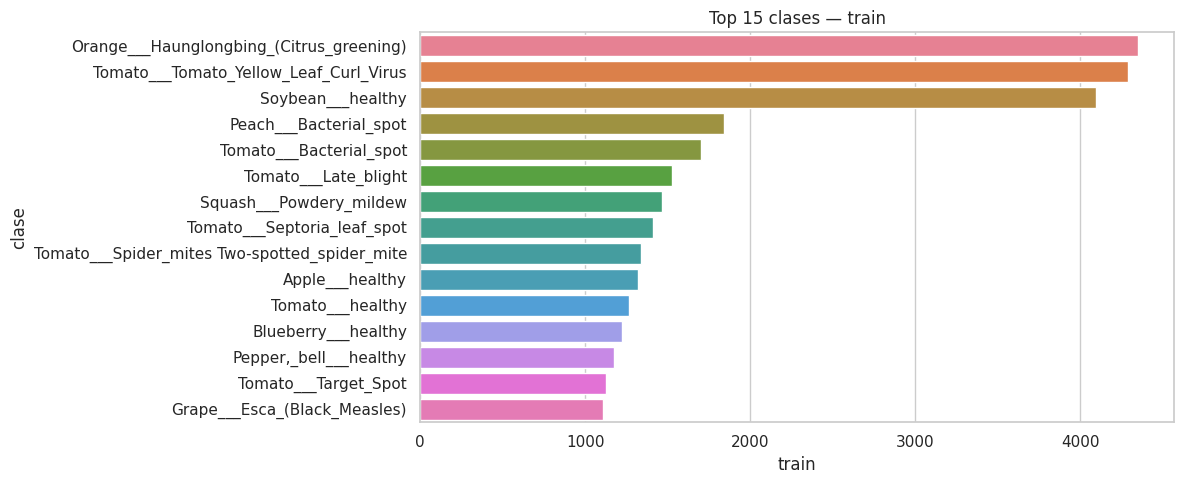

In [5]:
top = df.nlargest(15, "train")
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top, y="clase", x="train", ax=ax, hue="clase", legend=False)
ax.set_title("Top 15 clases — train")
plt.tight_layout()
fig.savefig(OUT_DIR / "01_class_distribution_top15.png", dpi=120)
plt.show()

## 3. Por planta y condición

In [6]:
def parse_label(name):
    if "___" in name:
        p, d = name.split("___", 1)
        return p.replace("_", " "), d.replace("_", " ")
    return name, "?"

df["planta"] = df["clase"].apply(lambda x: parse_label(x)[0])
df["condicion"] = df["clase"].apply(lambda x: parse_label(x)[1])
df["es_sano"] = df["condicion"].str.lower().eq("healthy")
print("Plantas:", df["planta"].nunique(), "| Clases healthy:", df["es_sano"].sum())
display(df.groupby("planta")["total"].sum().sort_values(ascending=False).head(10))

Plantas: 14 | Clases healthy: 12


planta
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn (maize)                3852
Apple                       3171
Peach                       2657
Pepper, bell                2474
Potato                      2152
Cherry (including sour)     1906
Name: total, dtype: int64

## 4. Muestras visuales

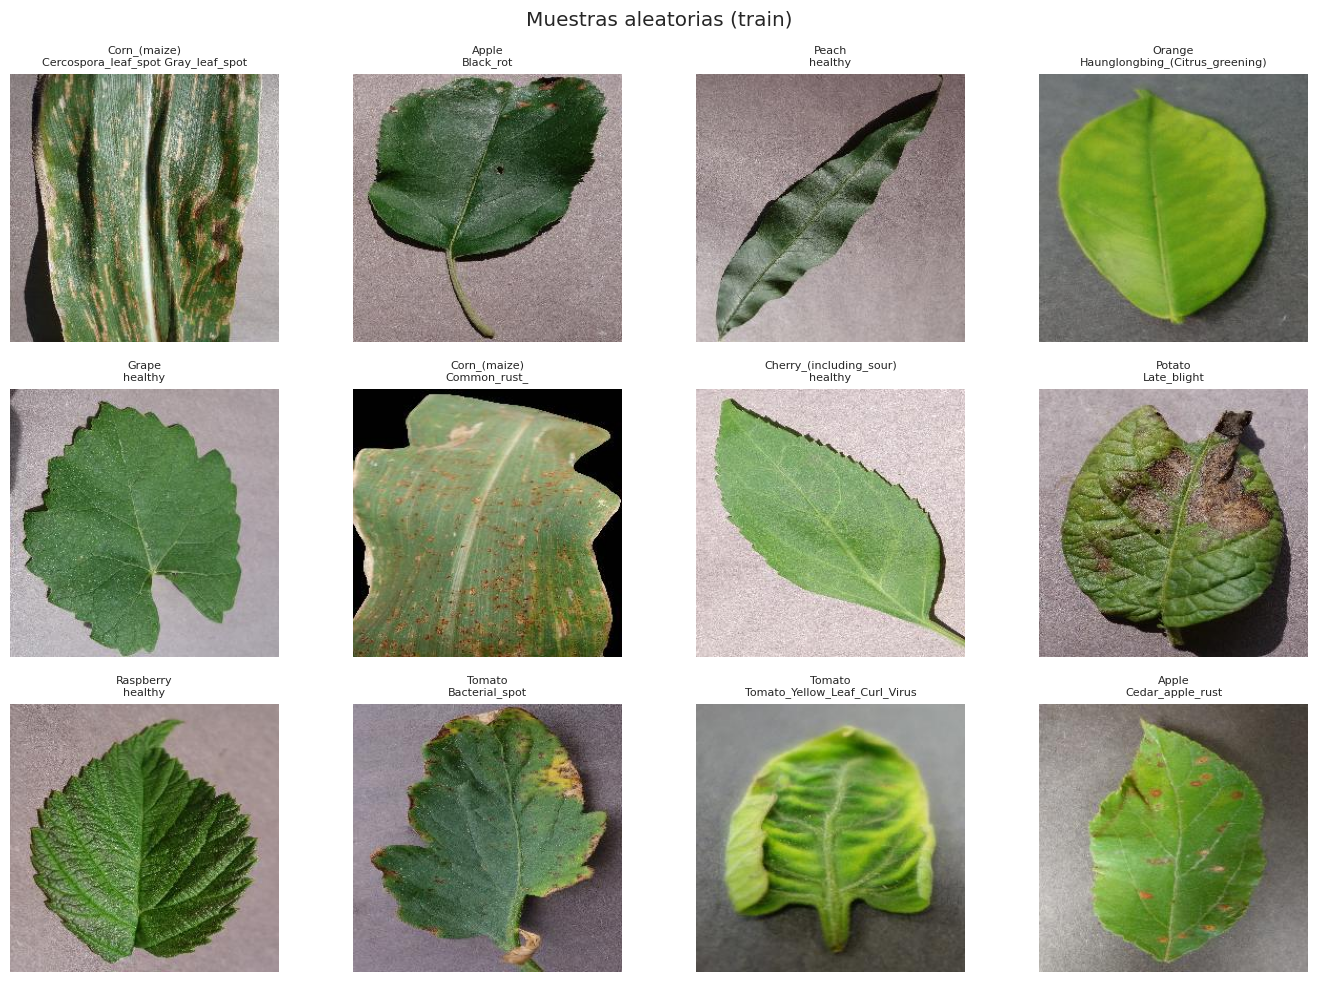

In [7]:
classes = sorted(train_counts.keys())
show = rng.sample(classes, min(12, len(classes)))

def get_img(cls):
    if USE_HF:
        idxs = [i for i, lb in enumerate(train_hf["class_label"]) if lb == cls]
        return train_hf[rng.choice(idxs)]["image"]
    ps = list((DATA_DIR / "train" / cls).glob("*"))
    return Image.open(rng.choice(ps)).convert("RGB")

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, cls in zip(axes.flat, show):
    ax.imshow(get_img(cls))
    ax.set_title(cls.replace("___", "\n"), fontsize=8)
    ax.axis("off")
plt.suptitle("Muestras aleatorias (train)")
plt.tight_layout()
fig.savefig(OUT_DIR / "03_sample_grid.png", dpi=120)
plt.show()

## 5. Tamaños de imagen

Ancho media 256px | Alto media 256px


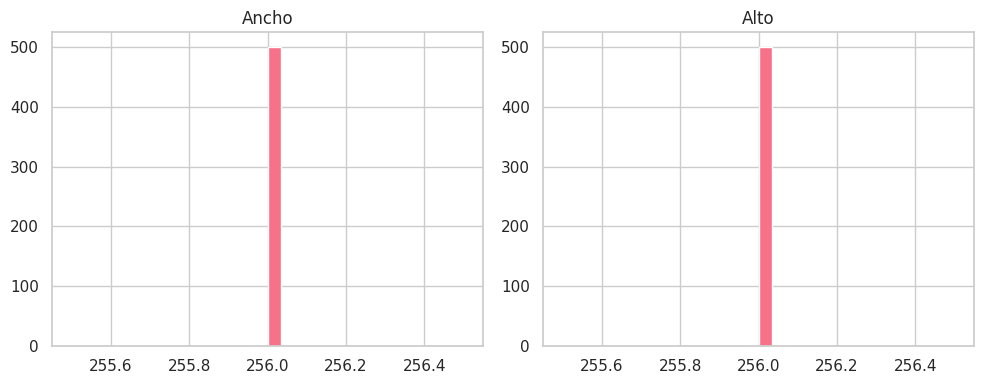

In [8]:
widths, heights = [], []
if USE_HF:
    idxs = rng.sample(range(len(train_hf)), min(500, len(train_hf)))
    for i in idxs:
        w, h = train_hf[i]["image"].size
        widths.append(w); heights.append(h)
else:
    paths = []
    for d in (DATA_DIR / "train").iterdir():
        if d.is_dir():
            paths.extend(list(d.glob("*"))[:15])
    for p in rng.sample(paths, min(500, len(paths))):
        with Image.open(p) as im:
            widths.append(im.size[0]); heights.append(im.size[1])
print(f"Ancho media {np.mean(widths):.0f}px | Alto media {np.mean(heights):.0f}px")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(widths, bins=30); ax[0].set_title("Ancho")
ax[1].hist(heights, bins=30); ax[1].set_title("Alto")
plt.tight_layout()
fig.savefig(OUT_DIR / "04_image_sizes.png", dpi=120)
plt.show()

## 6. Conclusiones

In [9]:
print("RESUMEN EDA")
print(f"  {n_classes} clases | train {n_train:,} | valid {n_valid:,}")
print(f"  Desbalance: {ratio:.1f}x | EfficientNet 224×224 recomendado")
if USE_HF:
    print("  Fuente: HF plantvillage-full. Export: python scripts/download_dataset_hf.py")
else:
    print(f"  Fuente: {DATA_DIR}")

RESUMEN EDA
  38 clases | train 43,356 | valid 10,948
  Desbalance: 36.2x | EfficientNet 224×224 recomendado
  Fuente: HF plantvillage-full. Export: python scripts/download_dataset_hf.py
